In [55]:
from randomness import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
seed = 42
np.random.seed(seed)
rng = np.random.default_rng(seed)

In [83]:
def plot_num_payers_vs_dif_mus(mus, num_payers, n):
    dif_mus = 2*mus
    num_payers = np.array(num_payers)
    plt.plot(dif_mus, num_payers, marker='o')   
    plt.xlabel("Difference in class means")
    plt.ylabel("Number of payers")
    plt.title("Number of payers vs Difference in class means n = {}".format(n))
    plt.grid()
    plt.show()


In [120]:
# # Example of data generation function
# def generate_data(n):
#     # Generate synthetic data
#     x, y = make_blobs(n_samples=n, centers=2, random_state=0, cluster_std=2.0)
#     y = np.where(y == 0, -1, y)
#     v = np.abs(x[:, 0]) * 10 + np.random.normal(0, 0.1, n)

#     # --- Center the data ---
#     scaler = StandardScaler(with_std=False) # Only subtracts the mean, doesn't scale std
#     x_centered = scaler.fit_transform(x)
#     # ---------------------------------

#     return x_centered, y, v

def generate_data_1d(n, mu1, mu2, sigma, rng):
    n_per_class = n // 2
    X1 = rng.normal(loc=mu1, scale=sigma, size=n_per_class)
    X2 = rng.normal(loc=mu2, scale=sigma, size=n_per_class)

    X = np.concatenate([X1, X2]).reshape(-1, 1)
    y = np.concatenate([
        -1 * np.ones(n_per_class),
        np.ones(n_per_class)
    ])

    v = np.ones(n)

    return X, y, v

def generate_data_2d(n, mu1, mu2, sigma, rng):
    n_per_class = n // 2
    X1 = rng.normal(loc=mu1, scale=sigma, size=(n_per_class, 2))
    X2 = rng.normal(loc=mu2, scale=sigma, size=(n_per_class, 2))
    X = np.vstack([X1, X2])
    y = np.concatenate([
        -1 * np.ones(n_per_class),
        np.ones(n_per_class)
    ])

    v = np.ones(n)

    return X, y, v



def generate_data_d(n, mu1, mu2, sigma, rng, d=1):
    n_per_class = n // 2
    X1 = rng.normal(loc=mu1, scale=sigma, size=(n_per_class, d))
    X2 = rng.normal(loc=mu2, scale=sigma, size=(n_per_class, d))
    X = np.vstack([X1, X2])
    y = np.concatenate([
        -1 * np.ones(n_per_class),
        np.ones(n_per_class)
    ])

    v = np.ones(n)

    return X, y, v

In [94]:
# 1. choose parameters 
n = 10
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' #TODO: add sigma 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
# TODO: k 
# TODO: fit_intercept 
# ---------------------------------
# 2. generate data in a sepearte function
#x,y,v = generate_data(n)

In [8]:
def update_data(x, y, mu1, mu2):
    X_new = x.copy()

    # shifts
    shift1 = mu1 - (1)
    shift2 = mu2 - (-1)

    X_new[y == -1] += shift1
    X_new[y == 1] += shift2

    return X_new

In [126]:
# 3. run exact simulation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 
T = 1
mus = np.linspace(1.0, 0.0, 4)
num_payers=[0]*len(mus)
for t in range(T):
    #x,y,v = generate_data(n, mu1 = 1, mu2 = -1 , sigma =1.0)
    for i, mu in enumerate(mus):
        mu1 = mu
        mu2 = -mu
        sigma = 1.0
        x,y,v = generate_data_d(n, mu1, mu2, sigma, rng, d=4)
        #x_updated = update_data(x, y, mu1, mu2)    
        df_exact, accuracy  = run_exact(x,y,v,c,use_loss, plot = show_plots)
        #print(df_exact)
        if df_exact is not None:
            num_payers[i] += len(df_exact)
        # print("_________________") 
num_payers = np.array(num_payers) / T  # average over t runs

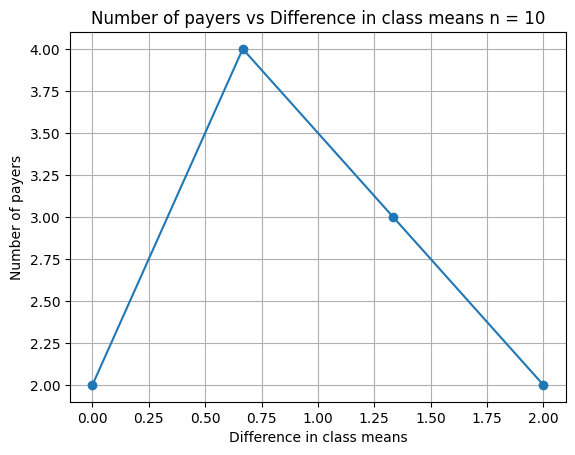

In [127]:
plot_num_payers_vs_dif_mus(mus, num_payers, n)